# Retail Analytics: RFM Segmentation & Revenue Forecasting

**Dataset:** UCI Online Retail Dataset  
**Tools:** PostgreSQL · Python (pandas, matplotlib)  
**Scope:** Sales trend analysis, RFM customer segmentation, and basic revenue forecasting

---

The dataset contains transactional records from a UK-based online retailer covering roughly one year (2010–2011). Each row represents a product sold in a given invoice, along with customer and country information.

The data was first loaded and cleaned in PostgreSQL, then pulled into Python for analysis and visualization.

## 1. Setup

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')


import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

load_dotenv()

user = os.getenv("POSTGRES_USER")
password = os.getenv("POSTGRES_PASSWORD")
host = os.getenv("POSTGRES_HOST", "localhost")
port = os.getenv("POSTGRES_PORT", "5432")
database = os.getenv("POSTGRES_DB", "retail_db")

engine = create_engine(
    f"postgresql+psycopg2://{user}:{quote_plus(password)}@{host}:{port}/{database}"
)

pd.read_sql("SELECT 1 AS connected", engine)

,connected
0,1


## 2. Data Cleaning (done in SQL)

All cleaning was handled directly in PostgreSQL before pulling data into Python. The steps were:

- **Removed rows with null `CustomerID`** — transactions without a customer ID can't be used for customer-level analysis
- **Removed rows where `Quantity <= 0`** — these records were excluded from the sales analysis because they may represent returns, cancellations, or other non-positive quantity transactions.
- **Fixed the `InvoiceDate` column** — the raw CSV stored dates as text (`MM/DD/YYYY HH:MI`), so a new `TIMESTAMP` column was created using `TO_TIMESTAMP()`, and the old column was dropped
- **Added `TotalPrice`** — calculated as `Quantity × UnitPrice` to get the revenue per line item

The full SQL script is in `Sales_analysis.sql`.

## 3. Pulling Data from PostgreSQL

In [28]:
# Note: PostgreSQL returns column aliases in lowercase regardless of how they're written in SQL
monthly = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', invoicedate) AS month,
        SUM(totalprice) AS revenue
    FROM retail_data
    GROUP BY month
    ORDER BY month;
""", engine)

# Rename to title case for cleaner display throughout the notebook
monthly.columns = ['Month', 'Revenue']
monthly['Month'] = pd.to_datetime(monthly['Month'])

monthly.head()

,Month,Revenue
0,2010-12-01,572713.890
1,2011-01-01,569445.040
2,2011-02-01,447137.350
3,2011-03-01,595500.760
4,2011-04-01,469200.361


In [29]:
# Customer-level summary for RFM
customer = pd.read_sql("""
    SELECT
        customerid,
        COUNT(DISTINCT invoiceno) AS frequency,
        SUM(totalprice)           AS monetary,
        MAX(invoicedate)          AS lastpurchase
    FROM retail_data
    GROUP BY customerid;
""", engine)

# Rename to title case
customer.columns = ['CustomerID', 'Frequency', 'Monetary', 'LastPurchase']

customer.head()

,CustomerID,Frequency,Monetary,LastPurchase
0,12346.0,1,77183.60,2011-01-18 10:01:00
1,12347.0,7,4310.00,2011-12-07 15:52:00
2,12348.0,4,1797.24,2011-09-25 13:13:00
3,12349.0,1,1757.55,2011-11-21 09:51:00
4,12350.0,1,334.40,2011-02-02 16:01:00


In [30]:
# Top 10 products by quantity sold
top_products = pd.read_sql("""
    SELECT
        description,
        SUM(quantity) AS totalsold
    FROM retail_data
    GROUP BY description
    ORDER BY totalsold DESC
    LIMIT 10;
""", engine)

top_products.columns = ['Description', 'TotalSold']
top_products

,Description,TotalSold
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
3,JUMBO BAG RED RETROSPOT,46181
4,WHITE HANGING HEART T-LIGHT HOLDER,36725
5,ASSORTED COLOUR BIRD ORNAMENT,35362
6,PACK OF 72 RETROSPOT CAKE CASES,33693
7,POPCORN HOLDER,30931
8,RABBIT NIGHT LIGHT,27202
9,MINI PAINT SET VINTAGE,26076


## 4. Sales Trend Analysis

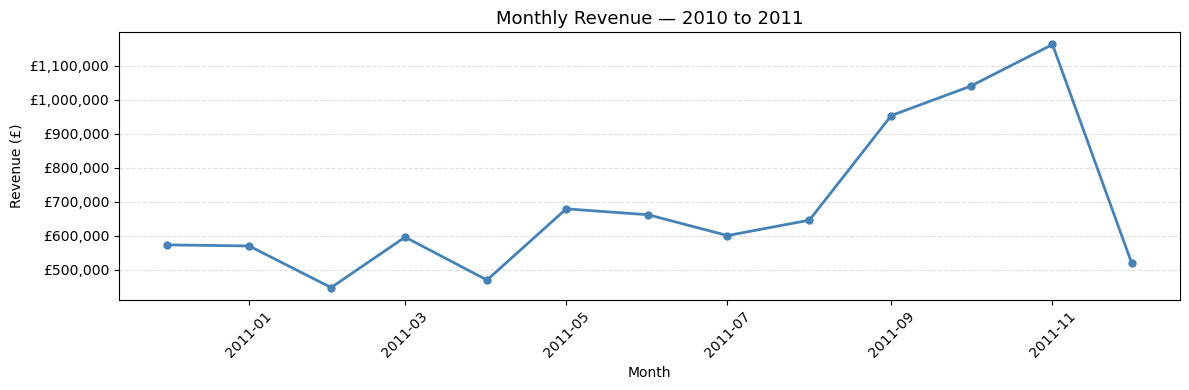

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Month'], monthly['Revenue'], marker='o', color='steelblue', linewidth=2, markersize=5)
ax.set_title('Monthly Revenue — 2010 to 2011', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

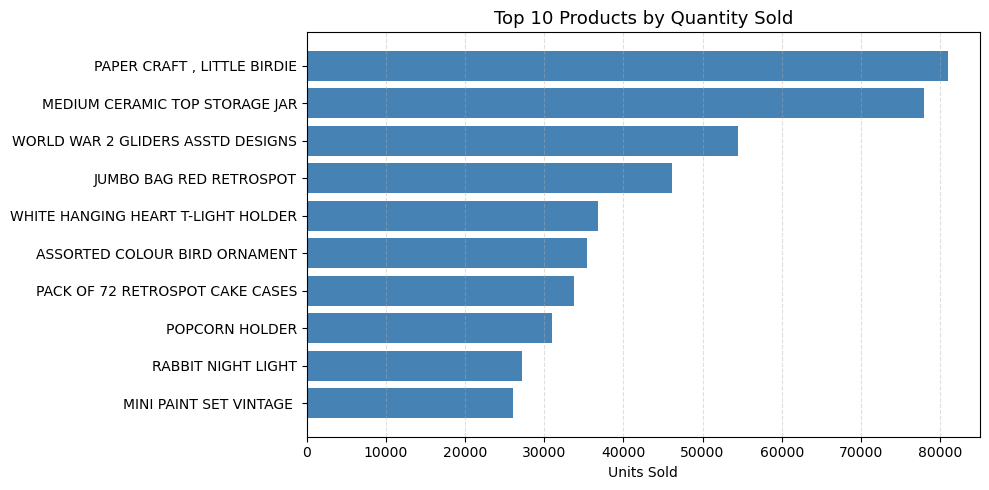

In [32]:
# Top 10 products
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_products['Description'][::-1], top_products['TotalSold'][::-1], color='steelblue')
ax.set_title('Top 10 Products by Quantity Sold', fontsize=13)
ax.set_xlabel('Units Sold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. RFM Customer Segmentation

RFM stands for Recency, Frequency, and Monetary — three dimensions that summarize customer purchasing behavior.

- **Recency** — how recently a customer placed an order (fewer days = better)
- **Frequency** — how many times they've ordered
- **Monetary** — how much they've spent in total

Each customer receives a score from 1–4 for Recency, Frequency, and Monetary value. These individual RFM scores are then used to assign customers to behavioral segments.

The combined RFM_Score is retained as a summary identifier for each customer's three scores.

Because many customers have identical order frequencies, Frequency values are ranked before quartile scoring so that four scoring groups can be created.

In [33]:
customer['LastPurchase'] = pd.to_datetime(customer['LastPurchase'])

# Snapshot date = one day after the last transaction in the dataset
snapshot_date = customer['LastPurchase'].max() + pd.Timedelta(days=1)
customer['Recency'] = (snapshot_date - customer['LastPurchase']).dt.days

print(f"Reference date used: {snapshot_date.date()}")
customer[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head()

Reference date used: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [34]:
# Score each RFM dimension on a 1–4 scale using quartiles

# Recency:
# Lower number of days = more recent = better score
customer['R_score'] = pd.qcut(
    customer['Recency'],
    q=4,
    labels=[4, 3, 2, 1],
    duplicates='drop'
)

# Frequency:
# Higher number of orders = better score

f_rank = customer['Frequency'].rank(method='first')

customer['F_score'] = pd.qcut(
    f_rank,
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)


# Monetary:
# Higher spending = better score
m_bins = pd.qcut(
    customer['Monetary'],
    q=4,
    duplicates='drop'
)

customer['M_score'] = m_bins.cat.codes + 1

# Convert scores to numeric
customer['R_score'] = customer['R_score'].astype(int)
customer['F_score'] = customer['F_score'].astype(int)
customer['M_score'] = customer['M_score'].astype(int)

# Combined RFM score
customer['RFM_Score'] = (
    customer['R_score'].astype(str) +
    customer['F_score'].astype(str) +
    customer['M_score'].astype(str)
)

customer[
    ['CustomerID', 'R_score', 'F_score', 'M_score', 'RFM_Score']
].head()

,CustomerID,R_score,F_score,M_score,RFM_Score
0,12346.0,1,1,4,114
1,12347.0,4,4,4,444
2,12348.0,2,3,4,234
3,12349.0,3,1,4,314
4,12350.0,1,1,2,112


In [35]:
# Assign customer segments using all three RFM dimensions

def segment(row):

    # Strong performance across all three dimensions
    if (
        row['R_score'] >= 3
        and row['F_score'] >= 3
        and row['M_score'] >= 3
    ):
        return 'High Value'

    # Recent and reasonably active customers
    elif (
        row['R_score'] >= 3
        and row['F_score'] >= 2
    ):
        return 'Loyal'

    # Everyone else
    else:
        return 'Low Value'


customer['Segment'] = customer.apply(
    segment,
    axis=1
)

customer['Segment'].value_counts()

Segment
Low Value     2410
High Value    1319
Loyal          610
Name: count, dtype: int64

In [36]:
segment_summary = customer.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Revenue=('Monetary', 'sum')
)

segment_summary['Customer_%'] = (
    segment_summary['Customers'] / len(customer) * 100
)

segment_summary['Revenue_%'] = (
    segment_summary['Revenue'] / segment_summary['Revenue'].sum() * 100
)

segment_summary.round(2)

,Customers,Revenue,Customer_%,Revenue_%
Segment,,,,
High Value,1319,6506541.99,30.40,73.01
Low Value,2410,1900195.08,55.54,21.32
Loyal,610,504670.83,14.06,5.66


### Segment Definitions

- **High Value:** R_score ≥ 3, F_score ≥ 3, and M_score ≥ 3
- **Loyal:** R_score ≥ 3 and F_score ≥ 2, excluding customers already classified as High Value
- **Low Value:** All remaining customers

High Value is checked first in the segmentation logic, so customers meeting the High Value criteria are not also classified as Loyal.

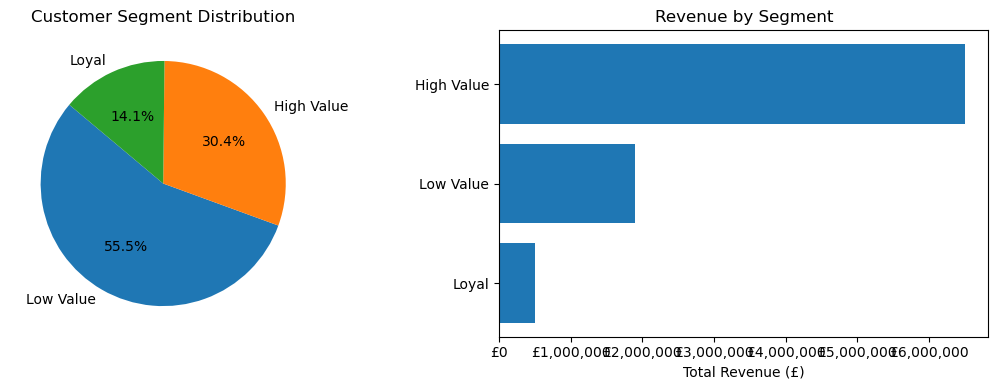

In [37]:
# Segment distribution chart

counts = customer['Segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140
)

axes[0].set_title('Customer Segment Distribution')

rev_by_seg = (
    customer.groupby('Segment')['Monetary']
    .sum()
    .sort_values()
)

axes[1].barh(
    rev_by_seg.index,
    rev_by_seg.values
)

axes[1].set_title('Revenue by Segment')
axes[1].set_xlabel('Total Revenue (£)')

axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'£{x:,.0f}'
    )
)

plt.tight_layout()
plt.show()

## 6. Revenue Forecasting

Monthly aggregation provides too few observations for meaningful model evaluation, so revenue is aggregated weekly.

The incomplete final week is excluded. The remaining data is divided chronologically into training, validation, and final test periods.

Three forecasting approaches are compared:

- Naive forecast
- 4-week moving average
- Holt exponential smoothing

The validation period is used for model selection, while the final test period remains unseen until final evaluation.

Complete weeks available: 52
Training weeks:    36
Validation weeks:  8
Testing weeks:     8

Validation Results


,Model,MAE,RMSE,MAPE (%)
0,Naive,64629.73,86563.38,27.50
1,4-Week Moving Average,58058.38,79959.56,24.91
2,Holt Exponential Smoothing,57692.24,79195.12,24.76



Selected model based on validation MAPE: Holt Exponential Smoothing

Final Test Results


,Model,MAE,RMSE,MAPE (%)
0,Naive,46859.36,51149.77,19.61
1,4-Week Moving Average,14782.39,19779.83,6.36
2,Holt Exponential Smoothing,42475.11,47821.35,17.30


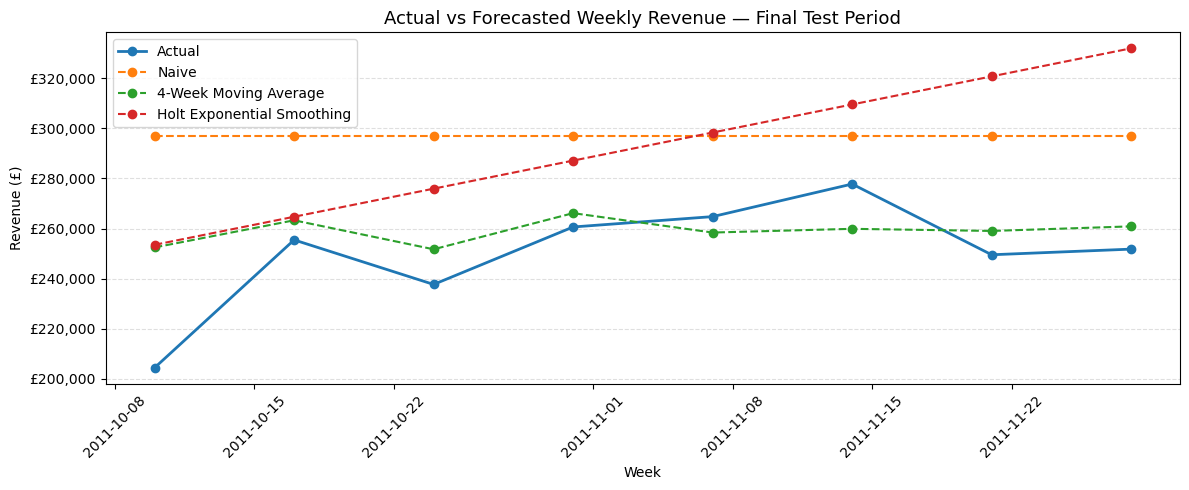

In [38]:
# Weekly Revenue Forecasting
# Train / Validation / Test Evaluation

# Pull weekly revenue directly from PostgreSQL
weekly = pd.read_sql("""
    SELECT
        DATE_TRUNC('week', invoicedate) AS week,
        SUM(totalprice) AS revenue
    FROM retail_data
    GROUP BY week
    ORDER BY week;
""", engine)

weekly.columns = ['Week', 'Revenue']
weekly['Week'] = pd.to_datetime(weekly['Week'])

# Exclude incomplete final week
weekly_model = weekly[
    weekly['Week'] < weekly['Week'].max()
].copy()

weekly_model = weekly_model.sort_values(
    'Week'
).reset_index(drop=True)

print(f"Complete weeks available: {len(weekly_model)}")


# --------------------------------------------------
# Train / Validation / Test Split
# --------------------------------------------------

train_size = 36
validation_size = 8
test_size = 8

train = weekly_model.iloc[
    :train_size
].copy()

validation = weekly_model.iloc[
    train_size:train_size + validation_size
].copy()


test = weekly_model.iloc[
    train_size + validation_size:
    train_size + validation_size + test_size
].copy()

assert len(test) == test_size, (
    f"Expected {test_size} test weeks, got {len(test)}"
)


print(f"Training weeks:    {len(train)}")
print(f"Validation weeks:  {len(validation)}")
print(f"Testing weeks:     {len(test)}")


# --------------------------------------------------
# Evaluation Function
# --------------------------------------------------

def calculate_metrics(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = np.mean(
        np.abs(actual - predicted)
    )

    rmse = np.sqrt(
        np.mean((actual - predicted) ** 2)
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    return mae, rmse, mape


# --------------------------------------------------
# Function to Generate Forecasts
# --------------------------------------------------

def generate_forecasts(train_data, forecast_size):

    history = train_data['Revenue'].tolist()

    # -----------------------------
    # Naive Forecast
    # -----------------------------

    naive_predictions = []

    temp_history = history.copy()

    for _ in range(forecast_size):

        prediction = temp_history[-1]

        naive_predictions.append(prediction)

        # For future forecasting, use the prediction
        temp_history.append(prediction)


    # -----------------------------
    # 4-Week Moving Average
    # -----------------------------

    moving_average_predictions = []

    temp_history = history.copy()

    for _ in range(forecast_size):

        prediction = np.mean(
            temp_history[-4:]
        )

        moving_average_predictions.append(
            prediction
        )

        temp_history.append(
            prediction
        )


    # -----------------------------
    # Holt Exponential Smoothing
    # -----------------------------

    from statsmodels.tsa.holtwinters import ExponentialSmoothing

    holt_model = ExponentialSmoothing(
        train_data['Revenue'],
        trend='add',
        seasonal=None,
        initialization_method='estimated'
    )

    holt_fit = holt_model.fit(
        optimized=True
    )

    holt_predictions = holt_fit.forecast(
        forecast_size
    ).tolist()


    return (
        naive_predictions,
        moving_average_predictions,
        holt_predictions
    )


# --------------------------------------------------
# Validation Evaluation
# --------------------------------------------------

(
    val_naive,
    val_moving_average,
    val_holt
) = generate_forecasts(
    train,
    validation_size
)


val_naive_mae, val_naive_rmse, val_naive_mape = calculate_metrics(
    validation['Revenue'],
    val_naive
)

val_ma_mae, val_ma_rmse, val_ma_mape = calculate_metrics(
    validation['Revenue'],
    val_moving_average
)

val_holt_mae, val_holt_rmse, val_holt_mape = calculate_metrics(
    validation['Revenue'],
    val_holt
)


validation_results = pd.DataFrame({
    'Model': [
        'Naive',
        '4-Week Moving Average',
        'Holt Exponential Smoothing'
    ],

    'MAE': [
        val_naive_mae,
        val_ma_mae,
        val_holt_mae
    ],

    'RMSE': [
        val_naive_rmse,
        val_ma_rmse,
        val_holt_rmse
    ],

    'MAPE (%)': [
        val_naive_mape,
        val_ma_mape,
        val_holt_mape
    ]
})

validation_results[
    ['MAE', 'RMSE', 'MAPE (%)']
] = validation_results[
    ['MAE', 'RMSE', 'MAPE (%)']
].round(2)

print("\nValidation Results")
display(validation_results)


# --------------------------------------------------
# Select Model Using Validation MAPE
# --------------------------------------------------

best_model = validation_results.loc[
    validation_results['MAPE (%)'].idxmin(),
    'Model'
]

print(f"\nSelected model based on validation MAPE: {best_model}")


# --------------------------------------------------
# Final Test Evaluation
# --------------------------------------------------

# Combine training + validation data.
# The test set remains completely unseen.

development_data = pd.concat(
    [train, validation],
    ignore_index=True
)


(
    test_naive,
    test_moving_average,
    test_holt
) = generate_forecasts(
    development_data,
    test_size
)


test_naive_mae, test_naive_rmse, test_naive_mape = calculate_metrics(
    test['Revenue'],
    test_naive
)

test_ma_mae, test_ma_rmse, test_ma_mape = calculate_metrics(
    test['Revenue'],
    test_moving_average
)

test_holt_mae, test_holt_rmse, test_holt_mape = calculate_metrics(
    test['Revenue'],
    test_holt
)


test_results = pd.DataFrame({
    'Model': [
        'Naive',
        '4-Week Moving Average',
        'Holt Exponential Smoothing'
    ],

    'MAE': [
        test_naive_mae,
        test_ma_mae,
        test_holt_mae
    ],

    'RMSE': [
        test_naive_rmse,
        test_ma_rmse,
        test_holt_rmse
    ],

    'MAPE (%)': [
        test_naive_mape,
        test_ma_mape,
        test_holt_mape
    ]
})

test_results[
    ['MAE', 'RMSE', 'MAPE (%)']
] = test_results[
    ['MAE', 'RMSE', 'MAPE (%)']
].round(2)

print("\nFinal Test Results")
display(test_results)


# --------------------------------------------------
# Actual vs Predicted — Final Test Period
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    test['Week'],
    test['Revenue'],
    marker='o',
    linewidth=2,
    label='Actual'
)

ax.plot(
    test['Week'],
    test_naive,
    marker='o',
    linestyle='--',
    label='Naive'
)

ax.plot(
    test['Week'],
    test_moving_average,
    marker='o',
    linestyle='--',
    label='4-Week Moving Average'
)

ax.plot(
    test['Week'],
    test_holt,
    marker='o',
    linestyle='--',
    label='Holt Exponential Smoothing'
)

ax.set_title(
    'Actual vs Forecasted Weekly Revenue — Final Test Period',
    fontsize=13
)

ax.set_xlabel('Week')
ax.set_ylabel('Revenue (£)')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'£{x:,.0f}'
    )
)

ax.tick_params(
    axis='x',
    rotation=45
)

ax.legend()

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

## 7. Key Findings

### Sales Trend

Revenue remains relatively moderate during much of the dataset and increases substantially during the later months, particularly around September–November. The December decline should be interpreted cautiously because the dataset ends partway through December.

### Product Analysis

The top 10 products by quantity sold were identified using SQL aggregation. This provides a view of which products contribute most to unit volume.

### Customer Segmentation

The RFM analysis identifies three customer segments: High Value, Loyal, and Low Value.

High Value customers represent approximately 30.4% of customers but contribute approximately 73.0% of total revenue, showing that revenue is concentrated among a smaller portion of customers.


### Revenue Forecasting

Weekly forecasting was used because the monthly dataset contains too few observations for robust model evaluation.

Naive, 4-week moving average, and Holt exponential smoothing models were evaluated using chronological training, validation, and final test periods.

Holt exponential smoothing was selected based on the lowest validation MAPE. The final test results for all three models are reported separately to evaluate performance on unseen data.

## 8. Export

In [39]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

customer['Monetary'] = customer['Monetary'].round(2)
monthly['Revenue'] = monthly['Revenue'].round(2)
weekly_model['Revenue'] = weekly_model['Revenue'].round(2)

customer.to_csv(OUTPUT_DIR / "customer_rfm.csv", index=False)
monthly.to_csv(OUTPUT_DIR / "monthly_sales.csv", index=False)
weekly_model.to_csv(OUTPUT_DIR / "weekly_sales.csv", index=False)
validation_results.to_csv(
    OUTPUT_DIR / "forecast_validation_results.csv",
    index=False
)
test_results.to_csv(
    OUTPUT_DIR / "forecast_test_results.csv",
    index=False
)

print("Export completed successfully.")

Export completed successfully.
